# 🎯 Module 3 — Class 4 Homework: Feature Selection

**Topic:** Feature selection — mutual_info, correlation, RFE

## 📋 What you have to do

This notebook **already has working code**. Your job:

1. **Run every cell from top to bottom** — it should run with no errors.
2. **Add a comment on EVERY code cell** that explains what the cell does, in your own words.
   - Use `#` to write comments inside the code cell.
   - Write at least 1 short sentence per cell. Longer is better.
3. **Save your notebook** as `Module<X>_Class<Y>_<YourName>.ipynb` and submit.

**Example of a good commented cell:**

```python
# Count how many customers churned vs stayed
# value_counts() returns the number of rows for each unique value
df['Churn'].value_counts()
```

**Example of a BAD comment (do not do this):**

```python
# count
df['Churn'].value_counts()
```

---


In [ ]:
# === SETUP — run this first ===

# Import core libraries for data manipulation and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Silence warnings to keep the notebook output clean
import warnings; warnings.filterwarnings('ignore')

# Define the source URL for the IBM Telco Churn dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

# Load the remote CSV file into a pandas DataFrame
df = pd.read_csv(url)

# Convert 'TotalCharges' to numbers and replace empty spaces/errors with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Display the dimensions of the successfully loaded dataset
print('Loaded:', df.shape)

Loaded: (7043, 21)


### Cell 1 — prepare X (features) and y (target)

In [ ]:
# Map text labels to binary numbers (0 for No, 1 for Yes)
df['Churn_bin'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Define the list of numerical features we want to use
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

# Separate the input features (X)
X = df[num_cols]

# Separate the target label we want to predict (y)
y = df['Churn_bin']

# Print the dimensions of both X and y to ensure they match
print('X shape:', X.shape, '| y shape:', y.shape)

X shape: (7043, 4) | y shape: (7043,)


### Cell 2 — correlation between each feature and target

In [ ]:
corr = X.copy()# Create a copy of features to avoid modifying the original X DataFrame
corr = X.copy()

# Add the target column (Churn) to this temporary DataFrame
corr['Churn'] = y

# Calculate correlations with Churn and sort them from highest to lowest
corr.corr()['Churn'].sort_values(ascending=False)
corr['Churn'] = y
corr.corr()['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
MonthlyCharges,0.193356
SeniorCitizen,0.150889
TotalCharges,-0.198324
tenure,-0.352229


### Cell 3 — mutual information scores

In [ ]:
# Import the Mutual Information classifier for feature selection
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information scores between features and target
mi = mutual_info_classif(X, y, random_state=42)

# Convert scores into a pandas Series and sort from highest to lowest
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# Display the sorted scores rounded to 4 decimal places
mi_scores.round(4)

,0
tenure,0.0706
MonthlyCharges,0.0467
TotalCharges,0.0447
SeniorCitizen,0.0103


### Cell 4 — bar chart of mutual information scores

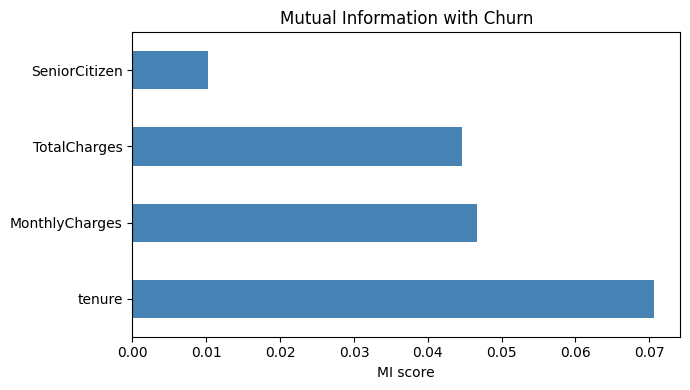

In [ ]:
# Set the width and height of the plot in inches
plt.figure(figsize=(7, 4))

# Plot the scores as a horizontal bar chart with steel blue bars
mi_scores.plot(kind='barh', color='steelblue')

# Add a descriptive title to the graph
plt.title('Mutual Information with Churn')

# Label the horizontal axis
plt.xlabel('MI score')

# Adjust layout automatically to prevent labels from getting cut off
plt.tight_layout()

# Render and display the plot on the screen
plt.show()

### Cell 5 — RFE: pick the top 2 features using LogisticRegression

In [ ]:
# Import feature selection and logistic regression tools
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale the data first since Logistic Regression is sensitive to data magnitude
X_scaled = StandardScaler().fit_transform(X)

# Set up RFE using Logistic Regression to pick the top 2 best features
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=2)

# Run the RFE algorithm to evaluate and rank the features
rfe.fit(X_scaled, y)

# Create a summary DataFrame showing which features were kept and their ranks
result = pd.DataFrame({'feature': X.columns, 'kept': rfe.support_, 'rank': rfe.ranking_})

# Sort the results by rank so the best features appear at the top
result.sort_values('rank')

,feature,kept,rank
0,tenure,True,1
1,MonthlyCharges,True,1
2,TotalCharges,False,2
3,SeniorCitizen,False,3


### Cell 6 — train a model with ALL features vs top 2 features

In [ ]:
# Import split and evaluation metrics from sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the scaled data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train a model using every single available feature
m_all = LogisticRegression(max_iter=1000).fit(X_train, y_train)

# Calculate and print the accuracy of the all-feature model
print('All features accuracy:', round(accuracy_score(y_test, m_all.predict(X_test)), 4))

# Get the column index numbers of the 2 best features chosen by RFE
top_idx = np.where(rfe.support_)[0]

# Train a new model using ONLY those 2 best features
m_top = LogisticRegression(max_iter=1000).fit(X_train[:, top_idx], y_train)

# Calculate and print the accuracy of the 2-feature model
print('Top 2 features accuracy:', round(accuracy_score(y_test, m_top.predict(X_test[:, top_idx])), 4))

All features accuracy: 0.8062
Top 2 features accuracy: 0.7984
